<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module4_Lab1_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4 — Decision Tree Classifier (Lab)
**Computer Vision · Machine Learning for Vision**

We train a decision tree on the Iris dataset (built-in, runs anywhere), tune it with grid search, inspect feature importances, and visualize the tree.

## 1. Imports & data

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

data = load_iris()
X, y = data.data, data.target
print("X:", X.shape, "| classes:", list(data.target_names))

X: (150, 4) | classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## 2. Split, train, evaluate a baseline tree

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=data.target_names))

Baseline accuracy: 0.9556
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.94      0.94      0.94        18
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



## 3. Hyperparameter tuning with GridSearchCV
Search over depth, leaf/split sizes, and the split criterion (`gini` vs `entropy`).

In [3]:
param_grid = {
    "max_depth": range(1, 10),
    "min_samples_leaf": range(1, 20, 2),
    "min_samples_split": range(2, 20, 2),
    "criterion": ["entropy", "gini"],
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=1), param_grid, cv=5, verbose=0)
grid.fit(X_train, y_train)
print("Best CV accuracy:", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)
best = grid.best_estimator_
print("Test accuracy (best):", round(best.score(X_test, y_test), 4))

Best CV accuracy: 0.9714
Best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}
Test accuracy (best): 0.9556


## 4. Feature importances
Which measurements does the tree rely on most?

In [4]:
for name, imp in sorted(zip(data.feature_names, best.feature_importances_), key=lambda t: -t[1]):
    print(f"{name:20s} {imp:.3f}")

petal width (cm)     0.923
petal length (cm)    0.077
sepal length (cm)    0.000
sepal width (cm)     0.000


## 5. Visualize the tree

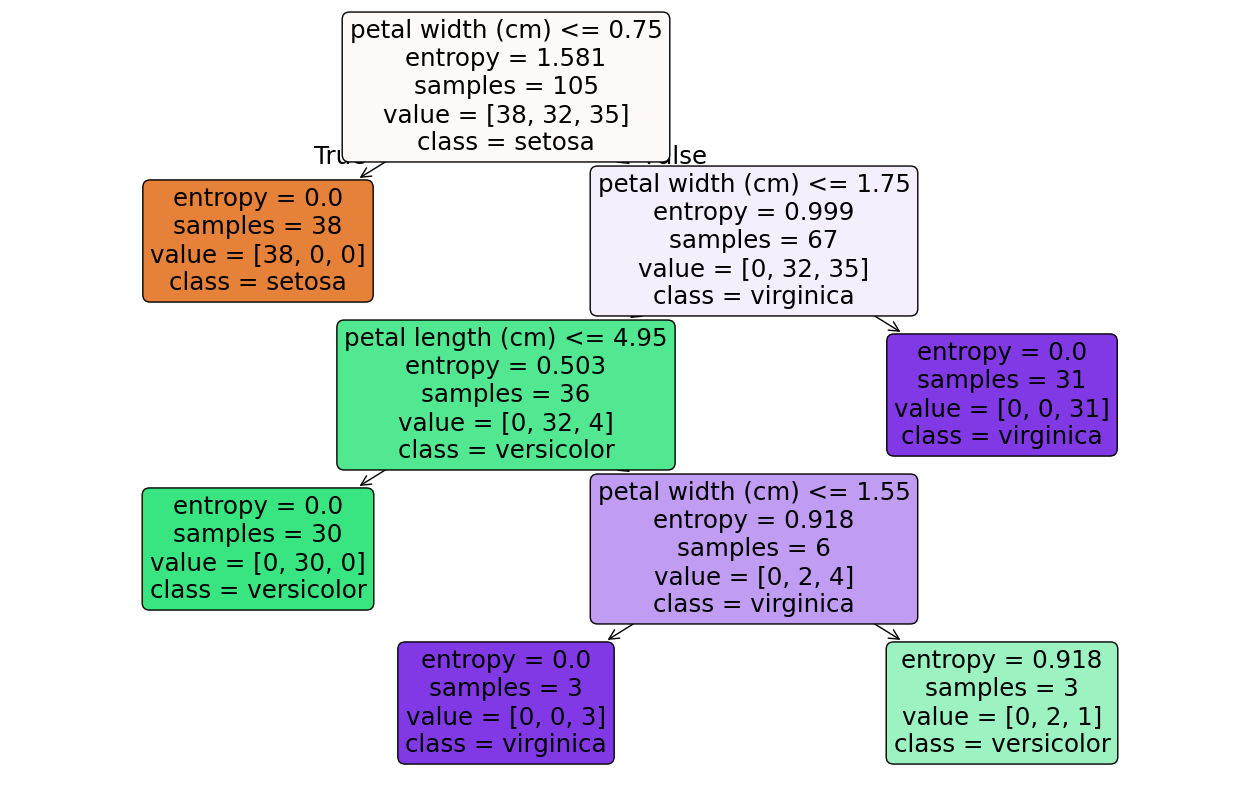

In [5]:
plt.figure(figsize=(16, 10))
plot_tree(best, filled=True, rounded=True,
          feature_names=data.feature_names, class_names=list(data.target_names))
plt.show()